# Class 3: Introduction to Networkx 2 — Graph Properties & Algorithms

Goal of today's class:
1. Continue exploring `networkx`
2. Build a base of useful functions for network analysis

*Acknowledgement: Much of the material in this lesson is based on a previous course offered by Matteo Chinazzi and Qian Zhang.*
__________

## Getting today's notebook

**Every class, duplicate the notebook before you run anything, and work in the copy.** Running a cell changes the file, and a changed original can block your next pull.

1. Log in to [Open OnDemand](https://ood.explorer.northeastern.edu/), open the **Courses** menu, and click **JupyterLab (Python)**. Launch it with the same settings as last class; they should already be filled in.
2. Once JupyterLab starts, open a terminal (**File → New → Terminal**) and pull the new material, where `USERNAME` is your Northeastern username:
   ```bash
   cd /courses/NETS7052.202710/students/USERNAME/nets7052_fa26
   git fetch upstream
   git checkout main
   git merge --no-edit upstream/main
   ```
   `--no-edit` is new. Once you've committed work of your own to your fork (Assignment 1, for example), this merge needs a commit message. `--no-edit` lets Git write that message itself instead of opening a text editor in your terminal.
3. **Duplicate today's notebook before you run anything.** In the file browser, open `notebooks/class_03_networkx2/`, right-click `class_03_networkx2.ipynb`, and choose **Duplicate**. Open the copy (`class_03_networkx2-Copy1.ipynb`) and work there.
4. Check that the top-right corner of the notebook says **Python (cmns-core)**. If it doesn't, choose **Kernel → Change Kernel…** and pick it.

**If the merge doesn't work:**

- *"Your local changes to the following files would be overwritten by merge"*: you changed a notebook that I've since updated, and Git lists which one. If you took notes in it, duplicate it first. Then close it and reset it, using the path Git listed:
  ```bash
  git restore notebooks/class_02_networkx1/class_02_networkx1.ipynb
  ```

  `git restore` throws away every change you made to that one file and puts back the version from your last pull. Git can't undo it, which is why you duplicate first. Then run `git merge --no-edit upstream/main` again.
- *"'upstream' does not appear to be a git repository"*: you missed a step in Class 0. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote add upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```
- **Git asks for a GitHub username or password:** don't type them. Your `upstream` address is wrong. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote set-url upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')
rc('axes', axisbelow=True)

# folders for the figures we save today
import os
os.makedirs('images/pngs', exist_ok=True)
os.makedirs('images/pdfs', exist_ok=True)

## Degree Distributions

### Erdős-Rényi Networks
In the limit for large $N$ the degree distribution $P(k)$ can be approximated by the Poisson distribution:

$$ P(k) = e^{-\langle k \rangle}\frac{\langle k \rangle^k}{k!} $$

Although, before that, it is defined by a Binomial distribution:

$$ P(k) = \binom{N-1}{k} p^k (1-p)^{N-k-1} $$

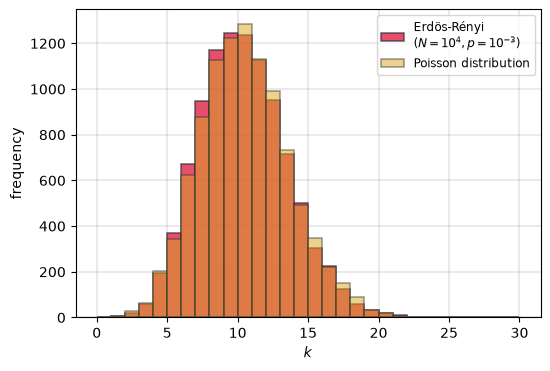

In [2]:
N = 10**4
p = 0.001
av_deg = (N-1)*p

num_bins = 20
bins = np.arange(0,31,1)

fig, ax = plt.subplots(1,1,figsize=(6,4),dpi=100)

g = nx.gnp_random_graph(N,p)
nd = np.array(list(dict(g.degree()).values()))

__ = ax.hist(nd, bins=bins, edgecolor='#333333', linewidth=1.1, color='crimson',
             alpha=0.75, label='Erdös-Rényi\n($N=10^{4}, p=10^{-3}$)')

k = np.random.poisson(av_deg, size=N)
__ = ax.hist(k, bins=bins, edgecolor='#333333', linewidth=1.1, color='goldenrod',
             alpha=0.5, label='Poisson distribution')

ax.legend(fontsize='small')
ax.grid(linewidth=1.5, color='#999999', alpha=0.2, linestyle='-')

ax.set_xlabel(r"$k$")
ax.set_ylabel("frequency")

plt.savefig('images/pngs/Pk_ER_vs_poisson.png', dpi=425, bbox_inches='tight')
plt.savefig('images/pdfs/Pk_ER_vs_poisson.pdf', bbox_inches='tight')
plt.show()

### Question: How do we generate poisson distributions without sampling + histograms?
###           What does this function do?
# from scipy.stats import poisson

________
### Beyond Random Graphs
#### Recall, from our last class:
**Source:** [Adamic, L. A., & Glance, N. (2005)](https://doi.org/10.1145/1134271.1134277). The political blogosphere and the 2004 US election: Divided they blog. In *Proceedings of the 3rd International Workshop on Link Discovery* (pp. 36-43).

In the following we will learn how to load a directed graph, extract a vertex-induced subgraph, and compute the in- and out-degree of the vertices of the graph. We will use a directed graph that includes a collection of hyperlinks between weblogs on US politics, recorded in 2005 by Adamic and Glance.

The data are included in two tab-separated files:
* `polblogs_nodes.tsv`: node id, node label, political orientation (0 = left or liberal, 1 = right or conservative).
* `polblogs_edges.tsv`: source node id, target node id. 

#### Step-by-step way to make this network:
1. One-by-one add nodes (blogs)
2. Connect nodes based on hyperlinks between blogs

In [3]:
digraph = nx.DiGraph()
with open('data/polblogs_nodes_class.tsv','r') as fp:
    for line in fp:
        node_id, node_label, node_political = line.strip().split('\t')
        political_orientation = 'liberal' if node_political == '0' else 'conservative'
        digraph.add_node(node_id, website=node_label, political_orientation=political_orientation)
        
with open('data/polblogs_edges_class.tsv','r') as fp:
    for line in fp:
        source_node_id, target_node_id = line.strip().split('\t')
        digraph.add_edge(source_node_id, target_node_id)
        
degree = digraph.degree()
in_degree = digraph.in_degree()
out_degree = digraph.out_degree()

# I usually make this a dictionary straight away
degree = dict(degree)
in_degree = dict(in_degree)
out_degree = dict(out_degree)

deg_vals = list(degree.values())
in_deg_vals = list(in_degree.values())
out_deg_vals = list(out_degree.values())

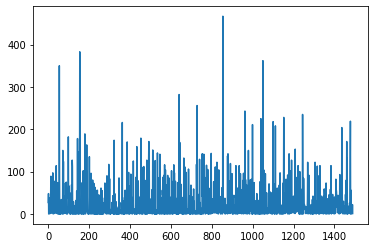

In [4]:
plt.plot(deg_vals)

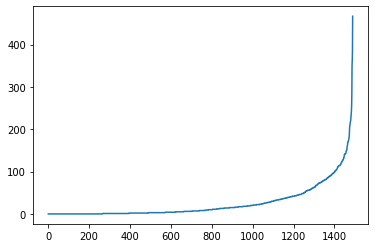

In [5]:
plt.plot(sorted(deg_vals))

In [6]:
from collections import Counter

In [7]:
min_deg = 0
max_deg = max(deg_vals)
deg_bins = {i:0 for i in range(min_deg, max_deg+1)}
for i,j in dict(Counter(deg_vals)).items():
    deg_bins[i] += j

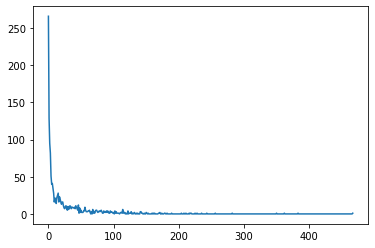

In [8]:
plt.plot(list(deg_bins.keys()),list(deg_bins.values()))

**Question**: Is this the most informative way to visualize this distribution?

##### Starting the class out with a challenge

In [9]:
def degree_distribution(G, number_of_bins=15, log_binning=True, density=True, directed=False):
    """
    Given a degree sequence, return the y values (probability) and the
    x values (support) of a degree distribution that you're going to plot.
    
    Parameters
    ----------
    G (nx.Graph):
        the network whose degree distribution to calculate

    number_of_bins (int):
        length of output vectors
    
    log_binning (bool):
        if you are plotting on a log-log axis, then this is useful
    
    density (bool):
        whether to return counts or probability density (default: True)
        Note: probability densities integrate to 1 but do not sum to 1. 

    directed (bool or str):
        if False, this assumes the network is undirected. Otherwise, the
        function requires an 'in' or 'out' as input, which will create the 
        in- or out-degree distributions, respectively.
        
    Returns
    -------
    bins_out, probs (np.ndarray):
        probability density if density=True node counts if density=False; binned edges
    
    """

    # Step 0: Do we want the directed or undirected degree distribution?
    if directed:
        if directed=='in':
            pass

        elif directed=='out':
            pass
            
        else:
            out_error = "Help! if directed!=False, the input needs to be either 'in' or 'out'"
            print(out_error)
            # Question: Is this the correct way to raise an error message in Python?
            #           See "raise" function...
            return out_error
    else:
        pass


    # Step 1: We will first need to define the support of our distribution
    kmax = np.max(k)    # get the maximum degree
    kmin = 0            # let's assume kmin must be 0


    # Step 2: Then we'll need to construct bins
    if log_binning:
        pass
    else:
        pass


    # Step 3: Then we can compute the histogram using numpy


    # Step 4: Return not the "bins" but the midpoint between adjacent bin
    #         values. This is a better way to plot the distribution.

    
    pass

    return bins_out, probs

____________

## Plotting Degree Distributions

The **degree distribution** $P(k)$ of *undirected* graphs is defined as the probability that any randomly chosen vertex has degree $k$.

In *directed* graphs, we need to consider two distributions: the **in-degree** $P(k_{in})$ and **out-degree** $P(k_{out})$ distributions, defined as the probability that a randomly chosen vertex has *in-degree* $k_{in}$ and *out-degree* $k_{out}$, respectively. 

In many real world networks, degree distributions are *skewed* and *highly variable* (i.e. the support of the distribution spans several orders of magnitude). In many cases, this **heavy tailed** behavior can be approximated by a power-law decay $P(k)\sim k^{-\alpha}$.

![https://networksciencebook.com/images/ch-04/figure-4-6.jpg](https://networksciencebook.com/images/ch-04/figure-4-6.jpg)

Source: https://networksciencebook.com/chapter/4#hubs

;) don't look below
_______________

In [10]:
def degree_distribution(G, number_of_bins=15, log_binning=True, density=True, directed=False):
    """
    Given a degree sequence, return the y values (probability) and the
    x values (support) of a degree distribution that you're going to plot.
    
    Parameters
    ----------
    G (nx.Graph):
        the network whose degree distribution to calculate

    number_of_bins (int):
        length of output vectors
    
    log_binning (bool):
        if you are plotting on a log-log axis, then this is useful
    
    density (bool):
        whether to return counts or probability density (default: True)
        Note: probability densities integrate to 1 but do not sum to 1. 

    directed (bool or str):
        if False, this assumes the network is undirected. Otherwise, the
        function requires an 'in' or 'out' as input, which will create the 
        in- or out-degree distributions, respectively.
        
    Returns
    -------
    bins_out, probs (np.ndarray):
        probability density if density=True node counts if density=False; binned edges
    
    """

    # Step 0: Do we want the directed or undirected degree distribution?
    if directed:
        if directed=='in':
            k = list(dict(G.in_degree()).values()) # get the in degree of each node
        elif directed=='out':
            k = list(dict(G.out_degree()).values()) # get the out degree of each node
        else:
            out_error = "Help! if directed!=False, the input needs to be either 'in' or 'out'"
            print(out_error)
            # Question: Is this the correct way to raise an error message in Python?
            #           See "raise" function...
            return out_error
    else:
        k = list(dict(G.degree()).values()) # get the degree of each node


    # Step 1: We will first need to define the support of our distribution
    kmax = np.max(k)    # get the maximum degree
    kmin = 0            # let's assume kmin must be 0


    # Step 2: Then we'll need to construct bins
    if log_binning:
        # array of bin edges including rightmost and leftmost
        bins = np.logspace(0, np.log10(kmax+1), number_of_bins+1)
    else:
        bins = np.linspace(0, kmax+1, num=number_of_bins+1)


    # Step 3: Then we can compute the histogram using numpy
    probs, _ = np.histogram(k, bins, density=density)


    # Step 4: Return not the "bins" but the midpoint between adjacent bin
    #         values. This is a better way to plot the distribution.
    bins_out = bins[1:] - np.diff(bins)/2.0
    
    return bins_out, probs

15 15


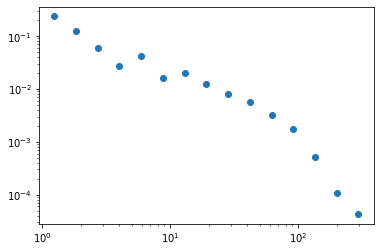

In [11]:
G0 = nx.to_undirected(digraph)
x, y = degree_distribution(G0)
print(len(x),len(y))

plt.loglog(x, y,marker='o',lw=0);

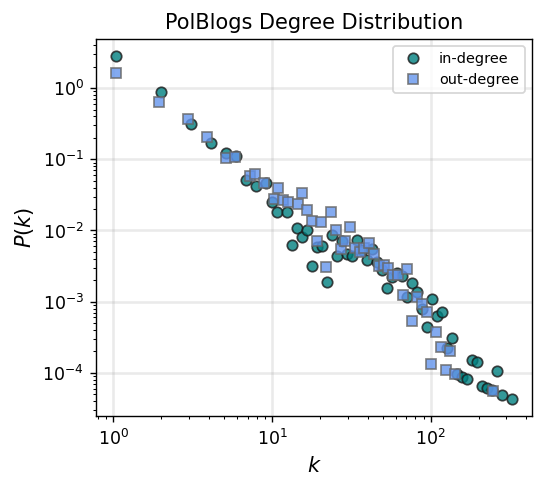

In [12]:
x_in, y_in  = degree_distribution(digraph, number_of_bins=80, log_binning=True, directed='in')
x_out,y_out = degree_distribution(digraph, number_of_bins=80, log_binning=True, directed='out')



fig, ax = plt.subplots(1,1,figsize=(4.5,4),dpi=125)

ax.loglog(x_in, y_in,'o', color='teal', label='in-degree', alpha=0.8, mec='.1')
ax.loglog(x_out, y_out,'s', color='cornflowerblue', label='out-degree', alpha=0.8, mec='.4')

ax.set_xlabel(r"$k$",fontsize='large')
ax.set_ylabel(r"$P(k)$",fontsize='large')
ax.legend(fontsize='small')
ax.grid(linewidth=1.5, color='#999999', alpha=0.2, linestyle='-')
ax.set_title('PolBlogs Degree Distribution')


plt.savefig('images/pngs/PolBlogs_inout_degreedist.png', dpi=425, bbox_inches='tight')
plt.savefig('images/pdfs/PolBlogs_inout_degreedist.pdf', bbox_inches='tight')
plt.show()

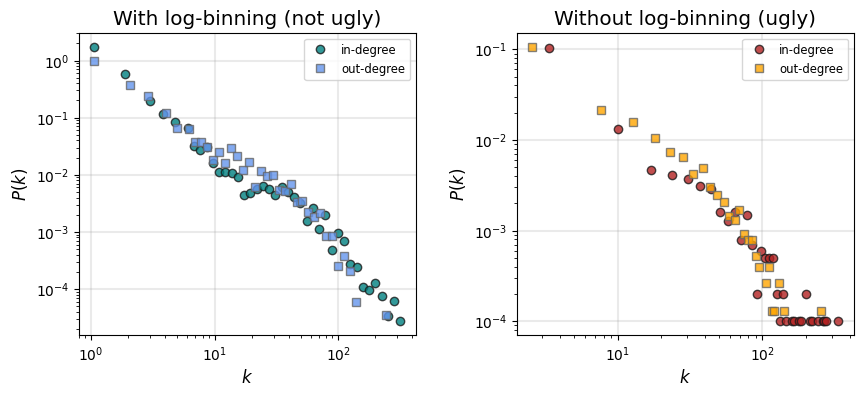

In [13]:
# Note: your plots will look stupid if you don't do log binning...
nbins = 50
fig, ax = plt.subplots(1,2,figsize=(10,4),dpi=100)
plt.subplots_adjust(wspace=0.3)

x_in, y_in  = degree_distribution(digraph, number_of_bins=nbins, log_binning=True, directed='in')
x_out,y_out = degree_distribution(digraph, number_of_bins=nbins, log_binning=True, directed='out')
ax[0].loglog(x_in, y_in, 'o', color='teal', label='in-degree', alpha=0.8, mec='.1')
ax[0].loglog(x_out, y_out, 's', color='cornflowerblue', label='out-degree', alpha=0.8, mec='.4')
ax[0].set_xlabel(r"$k$", fontsize='large')
ax[0].set_ylabel(r"$P(k)$", fontsize='large')
ax[0].legend(fontsize='small')
ax[0].grid(linewidth=1.5, color='#999999', alpha=0.2, linestyle='-')
ax[0].set_title('With log-binning (not ugly)', fontsize='x-large')

x_in, y_in  = degree_distribution(digraph, number_of_bins=nbins, log_binning=False, directed='in')
x_out,y_out = degree_distribution(digraph, number_of_bins=nbins, log_binning=False, directed='out')
ax[1].loglog(x_in, y_in, 'o', color='firebrick', label='in-degree', alpha=0.8, mec='.1')
ax[1].loglog(x_out, y_out, 's', color='orange', label='out-degree', alpha=0.8, mec='.4')
ax[1].set_xlabel(r"$k$", fontsize='large')
ax[1].set_ylabel(r"$P(k)$", fontsize='large')
ax[1].legend(fontsize='small')
ax[1].grid(linewidth=1.5, color='#999999', alpha=0.2, linestyle='-')
ax[1].set_title('Without log-binning (ugly)', fontsize='x-large')

plt.savefig('images/pngs/PolBlogs_inout_degreedist_binningcompare.png', dpi=425, bbox_inches='tight')
plt.savefig('images/pdfs/PolBlogs_inout_degreedist_binningcompare.pdf', bbox_inches='tight')
plt.show()

#### Note from Advanced Topics 4b in *Network Science* by Albert-László Barabási

https://networksciencebook.com/chapter/4#advanced-b

![](images/barabasi_log_binning.png)
![](images/barabasi_figure-4-22.png)

#### Using the network generator functions from last class...
*Your Turn!*

1. Generate 3 random graphs with roughly the same number of nodes and edges that the `polblogs` dataset has
2. Plot the degree distribution in the same plot as the true degree distribution
3. Write a few sentences that show what you've found
_______________

In [14]:
N = G0.number_of_nodes()
E = G0.number_of_edges()
print(N,E)

1490 16718


In [15]:
G1 = nx.gnm_random_graph(N,E) # same number of nodes and edges
G2 = nx.powerlaw_cluster_graph(N, 11, p=0.01) # same number of nodes, similar number of edges
G3 = nx.duplication_divergence_graph(N, 0.6698) # had to work at it, but approx same number of nodes + edges
# np.mean([nx.duplication_divergence_graph(N, 0.6698).number_of_edges() for i in range(100)])

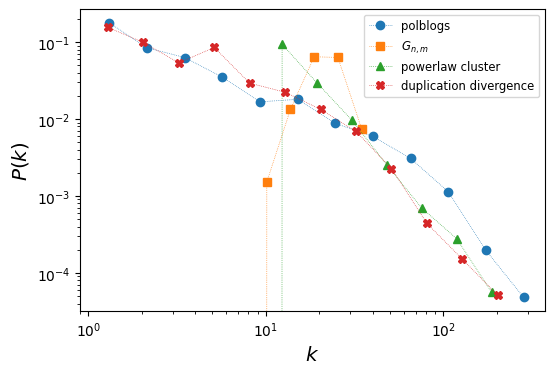

In [16]:
fig, ax = plt.subplots(1,1,figsize=(6,4),dpi=100)

x0,y0 = degree_distribution(G0, number_of_bins=12)
x1,y1 = degree_distribution(G1, number_of_bins=12)
x2,y2 = degree_distribution(G2, number_of_bins=12)
x3,y3 = degree_distribution(G3, number_of_bins=12)

ax.loglog(x0,y0,marker='o',lw=0.5,ls=':',label='polblogs')
ax.loglog(x1,y1,marker='s',lw=0.5,ls=':',label=r'$G_{n,m}$')
ax.loglog(x2,y2,marker='^',lw=0.5,ls=':',label='powerlaw cluster')
ax.loglog(x3,y3,marker='X',lw=0.5,ls=':',label='duplication divergence')

ax.legend(fontsize='small')
ax.set_xlabel(r'$k$',fontsize='x-large')
ax.set_ylabel(r'$P(k)$',fontsize='x-large')

plt.show()

________________

### Break

## Paths and Components

Let us define a __path__ $P_{i_0,i_n}$ in a graph $G = (V,E)$ as an *ordered collection* of vertices $\{i_0, i_1, \dots, i_n \}$ and $n$ edges $\{(i_0,i_1), (i_1,i_2), \dots, (i_{n-1},i_n) \}$ such that $i_a \in V$ and $(i_{a-1},i_a) \in E, \forall a$. The path $P_{i_0,i_n}$ connects nodes $i_0$ and $i_n$ and its **length** is $n$.

**Note:** The number of paths of length $n$ between two nodes $i$ and $j$ is equivalent to the element $i,j$ of the $n$th power of the adjacency matrix $A$.

- A **shortest-path** (or *geodesic path*) is the shortest path connecting two vertices.
- The **eccentricity** $\epsilon$ of a vertex $i$ is the longest shortest-path between vertex $i$ and any other vertex $j$.
- The **radius** $r$ of a graph $G=(V,E)$ is the *minimum* eccentricity of any node in $V$.
- The **diameter** $d$ of a graph $G=(V,E)$ is the *maximum* eccentricity of any node in $V$.
- A **cycle** (or loop) is a closed path (i.e. $i_0 = i_n$) in which all vertices and all edges are distinct. If a graph $G=(V,E)$ does not contain any cycle, then such a graph is said to be **acyclic**. Instead, if it contains at least one cycle, the graph is said to be **cyclic**.

**We'll be diving into paths more thoroughly in later lessons, but to kick things off today, let's define these terms above**... 

Starting with *shortest path*.

In [17]:
G = nx.karate_club_graph()

Question: What is our "shortest path" function meant to do?

1. **Goal: I want to know the shortest path from node *i* to node *j***.
2. **Goal: I want to know the shortest paths from all nodes *i* to all other nodes *j***.

In [18]:
node_i = 0
# For a given node i, let's initialize all other nodes to be -1 (infinite) hops away
distances = {i: -1 for i in G.nodes()}

# And distance of 0 from node_i to itself
distances[node_i] = 0

# I'll need to make a queue of nodes to search... How to do this?
pass

### Breadth-first search (BFS)
![images/BFS.gif](images/BFS.gif)
________

In [19]:
# Queue of nodes to visit next, starting with our source node_i
queue = [node_i]

# We want to:
### 1. Start with one element in our queue
### 2. Find its neighbors and add them to our queue
### 3. Select one of the neighbors from the queue
### 4. Add its neighbors to our queue
### 5. And so on, until the queue has been depleted

# This is a great time for a `while` loop!

# while there is still a queue of any positive length (instead of len(queue)>0)...
while queue:
    # select oldest item in the list (as opposed to last item)
    current_node = queue.pop(0)

    # find all the neighbors of the current node
    for next_node in G.neighbors(current_node):
        if distances[next_node] < 0:
            # set next_node's distance to be +1 whatever the distance to the current node is
            ### e.g. if current_node distance is 0, its neighbors will be 0+1 distance away
            ### ... and so on
            distances[next_node] = distances[current_node] + 1

            # and since we havent seen next_node before (distance still < 0)
            # we will need to append it to our queue
            queue.append(next_node)

In [20]:
pos = nx.spring_layout(G)

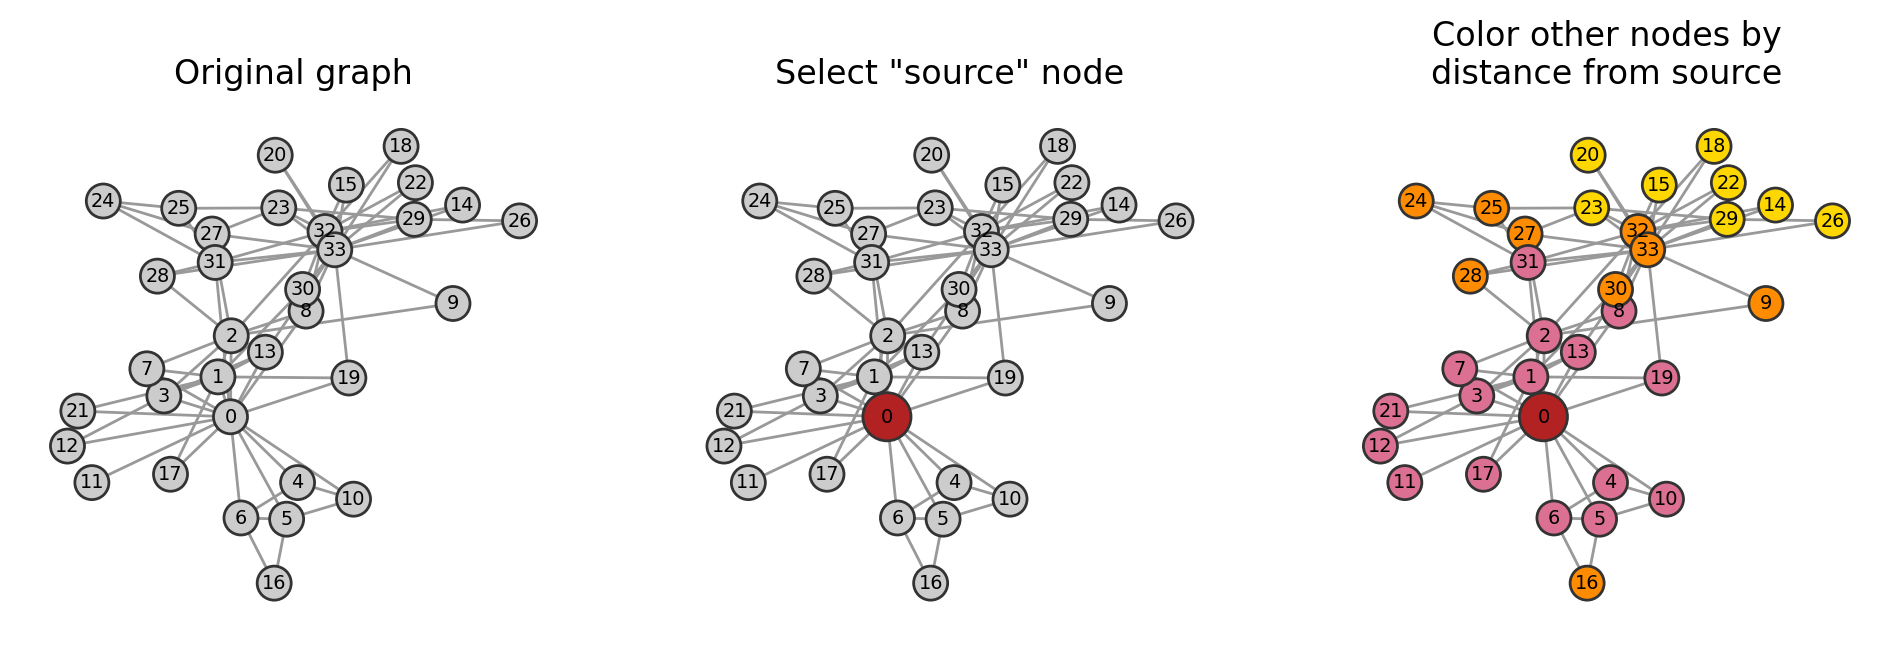

In [21]:
fig, ax = plt.subplots(1,3,figsize=(12,3.5),dpi=200)

dist_col_map = {0:'firebrick',
                1:'palevioletred',
                2:'darkorange',
                3:'gold'}

node_cols0 = ['.8' for i in G.nodes()]
nx.draw(G, pos, node_size=150, node_color=node_cols0, edgecolors='.2',
        with_labels=True, font_size='x-small', edge_color='.6', ax=ax[0])

node_cols1 = ['firebrick' if i==node_i else '.8' for i in G.nodes()]
nx.draw(G, pos, node_size=[300 if i==node_i else 150 for i in G.nodes()],
        node_color=node_cols1, edgecolors='.2',
        with_labels=True, font_size='x-small', edge_color='.6', ax=ax[1])

node_cols2 = [dist_col_map[i] for i in distances.values()]
nx.draw(G, pos, node_size=[300 if i==node_i else 150 for i in G.nodes()],
        node_color=node_cols2, edgecolors='.2',
        with_labels=True, font_size='x-small', edge_color='.6', ax=ax[2])

ax[0].set_title('Original graph')
ax[1].set_title('Select "source" node')
ax[2].set_title('Color other nodes by\ndistance from source')


plt.savefig('images/pngs/networkx_example_BFS.png', dpi=425, bbox_inches='tight')
plt.savefig('images/pdfs/networkx_example_BFS.pdf', bbox_inches='tight')

plt.show()

#### Putting it all together

**Your turn!**

Finish the function `all_shortest_from` below. We'll need it for an exercise shortly.

In [22]:
def all_shortest_from(G, node_i):
    """
    For a given node_i in the network, construct a dictionary containing
    the length of the shortest path between that node and all others in
    the network. Values of -1 correspond to nodes where no paths connect
    to node_i.
    
    Parameters
    ----------
    G (nx.Graph)
        the graph in question
    
    node_i (int or str)
        the label of the "source" node
    
    Returns
    -------
    distances (dict)
        dictionary where the key corresponds to other nodes in the network
        and the values indicate the shortest path length between that node
        and the original node_i source.
    
    """
    
    pass
    
    return distances

____________

In [23]:
def all_shortest_from(G, node_i):
    """
    For a given node_i in the network, construct a dictionary containing
    the length of the shortest path between that node and all others in
    the network. Values of -1 correspond to nodes where no paths connect
    to node_i.
    
    Parameters
    ----------
    G (nx.Graph)
        the graph in question
    
    node_i (int or str)
        the label of the "source" node
    
    Returns
    -------
    distances (dict)
        dictionary where the key corresponds to other nodes in the network
        and the values indicate the shortest path length between that node
        and the original node_i source.
    
    """
    
    distances = {i: -1 for i in G.nodes()}

    # And distance of 0 from node_i to itself
    distances[node_i] = 0

    # Queue of nodes to visit next, starting with our source node_i
    queue = [node_i]

    # We want to:
    ### 1. Start with one element in our queue
    ### 2. Find its neighbors and add them to our queue
    ### 3. Select one of the neighbors from the queue
    ### 4. Add its neighbors to our queue
    ### 5. And so on, until the queue has been depleted

    # This is a great time for a `while` loop!

    # while there is still a queue of any positive length (instead of len(queue)>0)...
    while queue:
        # select oldest item in the list (as opposed to last item)
        current_node = queue.pop(0)

        # find all the neighbors of the current node
        for next_node in G.neighbors(current_node):
            if distances[next_node] < 0:
                # set next_node's distance to be +1 whatever the distance to the current node is
                ### e.g. if current_node distance is 0, its neighbors will be 0+1 distance away
                ### ... and so on
                distances[next_node] = distances[current_node] + 1

                # and since we havent seen next_node before (distance still < 0)
                # we will need to append it to our queue
                queue.append(next_node)    
    
    return distances

#### From above:
- A **shortest-path** (or *geodesic path*) is the shortest path connecting two vertices.
- The **eccentricity** $\epsilon$ of a vertex $i$ is the longest shortest-path between vertex $i$ and any other vertex $j$.
- The **radius** $r$ of a graph $G=(V,E)$ is the *minimum* eccentricity of any node in $V$.
- The **diameter** $d$ of a graph $G=(V,E)$ is the *maximum* eccentricity of any node in $V$.
- A **cycle** (or loop) is a closed path (i.e. $i_0 = i_n$) in which all vertices and all edges are distinct. If a graph $G=(V,E)$ does not contain any cycle, then such a graph is said to be **acyclic**. Instead, if it contains at least one cycle, the graph is said to be **cyclic**.

**Your turn!**

1. Use your function `all_shortest_from` above to compute the shortest path lengths for every node in `G`.

2. Use this to calculate the following:
    - A) The **eccentricity** of all nodes in `G`
    - B) The **radius** of `G`
    - C) The **diameter** of `G`
    
3. Cross-reference your answer with the output from `networkx`.

In [24]:
pass

__________

In [25]:
print("Radius:",nx.radius(G))
print("Diameter:",nx.diameter(G))
print(nx.eccentricity(G))

Radius: 3
Diameter: 5
{0: 3, 1: 3, 2: 3, 3: 3, 4: 4, 5: 4, 6: 4, 7: 4, 8: 3, 9: 4, 10: 4, 11: 4, 12: 4, 13: 3, 14: 5, 15: 5, 16: 5, 17: 4, 18: 5, 19: 3, 20: 5, 21: 4, 22: 5, 23: 5, 24: 4, 25: 4, 26: 5, 27: 4, 28: 4, 29: 5, 30: 4, 31: 3, 32: 4, 33: 4}


_______________

### Segue: A special kind of "path"

Remember from above: The number of paths of length $l$ between two nodes $i$ and $j$ in a graph can be found in the $ij^{th}$ element of the $l^{th}$ power of the adjacency matrix $A$.

In [26]:
A = nx.to_numpy_array(G, weight=None)

In [27]:
A

array([[0., 1., 1., ..., 1., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]])

In [28]:
# recall that matrix multiplication in numpy is done as follows:
A @ A

array([[16.,  7.,  5., ...,  0.,  3.,  4.],
       [ 7.,  9.,  4., ...,  1.,  2.,  3.],
       [ 5.,  4., 10., ...,  3.,  1.,  6.],
       ...,
       [ 0.,  1.,  3., ...,  6.,  1.,  2.],
       [ 3.,  2.,  1., ...,  1., 12., 10.],
       [ 4.,  3.,  6., ...,  2., 10., 17.]])

Take a moment to interpret what this is showing.
- What do the diagonal elements correspond to?
- What do the off-diagonal elements correspond to?
- Is this matrix symmetric?

What if we take the third power, $A^3$, of the adjacency matrix?

In [29]:
A @ A @ A

array([[36., 37., 42., ..., 27., 12., 14.],
       [37., 24., 34., ..., 13., 11., 13.],
       [42., 34., 22., ..., 13., 32., 22.],
       ...,
       [27., 13., 13., ...,  6., 31., 36.],
       [12., 11., 32., ..., 31., 26., 40.],
       [14., 13., 22., ..., 36., 40., 30.]])

How does this operation relate to the `networkx` function `nx.triangles`?

In [30]:
pass

______

## Clustering 

Node degree tells us how many neighbors each vertex has. However, we might also want to know how one node's neighbors are related to each other. We can intuit this by imagining paths of length three in our graph. The concept of ***clustering*** (or *transitivity* in the context of sociology) refers exactly to this: the tendency for nodes to form cliques around a given vertex.

### Local Clustering

Given an ***undirected*** graph $G=(V,E)$, let us define the ***local clustering coefficient*** as the probability that any two neighbors $j$ and $k$ of node $i$ are connected:

$$ C(i) = 
\begin{cases}
    \frac{e_i}{k_i(k_i-1)/2}       & \quad \text{if } k_{i}>1\\
    0                              & \quad \text{if } k_{i}\leq 1\\
\end{cases},
$$

where $k_i$ is the degree of node $i$ and $e_i$ the number of edges that exists between the neighbors of node $i$. In other words, the clustering coefficient of a node represents the ratio between the number of triangles in the subgraph $G'$ induced by node $i$ and its neighbors over the number of all possible triangles that would be present if $G'$ was a complete graph.

The average clustering coefficient of a network, then, is simply: $\langle C \rangle = \frac{1}{N}\sum_i C(i)$.

In ***directed*** graphs, the definition of clustering can be further refined since 8 different types of triangles can be present in our graph; see [Fagiolo (2007)](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.76.026107).

In [31]:
G = nx.karate_club_graph()

In [32]:
# Step 1: Select a random node, i
i = 0

# Step 2: Get all the neighbors of node i
G.neighbors(i)

# Step 3: How do we get all the ***possible*** triangles?

#### Interlude: `itertools` — Functions creating iterators for efficient looping
This module implements a number of iterator building blocks inspired by constructs from APL, Haskell, and SML. Each has been recast in a form suitable for Python.

The module standardizes a core set of fast, memory efficient tools that are useful by themselves or in combination. Together, they form an “iterator algebra” making it possible to construct specialized tools succinctly and efficiently in pure Python.

Source: https://docs.python.org/3/library/itertools.html

In [33]:
from itertools import combinations # Return successive r-length combinations of elements in the iterable.

In [34]:
list1 = [1,2,3,4,5]
r = 1

list(combinations(list1, r))

[(1,), (2,), (3,), (4,), (5,)]

In [35]:
r = 2
list(combinations(list1, r))

[(1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (2, 3),
 (2, 4),
 (2, 5),
 (3, 4),
 (3, 5),
 (4, 5)]

In [36]:
node_i = 0
neighbors_i = list(G.neighbors(node_i))
print("node %i is connected to nodes:"%node_i,neighbors_i)

node 0 is connected to nodes: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]


In [37]:
possible_triangle_edges_i = list(combinations(neighbors_i,2))
print("The potential neighbor-neighbor edges among node %i's neighbors is:"%node_i,
      possible_triangle_edges_i, '\n\n(length = %i)'%len(possible_triangle_edges_i))

The potential neighbor-neighbor edges among node 0's neighbors is: [(1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 10), (1, 11), (1, 12), (1, 13), (1, 17), (1, 19), (1, 21), (1, 31), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 10), (2, 11), (2, 12), (2, 13), (2, 17), (2, 19), (2, 21), (2, 31), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 10), (3, 11), (3, 12), (3, 13), (3, 17), (3, 19), (3, 21), (3, 31), (4, 5), (4, 6), (4, 7), (4, 8), (4, 10), (4, 11), (4, 12), (4, 13), (4, 17), (4, 19), (4, 21), (4, 31), (5, 6), (5, 7), (5, 8), (5, 10), (5, 11), (5, 12), (5, 13), (5, 17), (5, 19), (5, 21), (5, 31), (6, 7), (6, 8), (6, 10), (6, 11), (6, 12), (6, 13), (6, 17), (6, 19), (6, 21), (6, 31), (7, 8), (7, 10), (7, 11), (7, 12), (7, 13), (7, 17), (7, 19), (7, 21), (7, 31), (8, 10), (8, 11), (8, 12), (8, 13), (8, 17), (8, 19), (8, 21), (8, 31), (10, 11), (10, 12), (10, 13), (10, 17), (10, 19), (10, 21), (10, 31), (11, 12), (11, 13), (11, 17), (11, 19), (11, 21), (11, 31), (1

Recall above: How many possible edges should we expect based on the equation above?

In [38]:
node_i = 0
k_i = G.degree(node_i)
print(k_i)

16


In [39]:
# according to the equation above, we know the denominator should be k_i(k_i-1)/2
possible_triangles_i = k_i * (k_i-1)/2
possible_triangles_i

# what is the numerator? **the number of edges between nodes that are neighbors of node_i**

120.0

In [40]:
actual_triangles_i = sum([1 for neigh_i,neigh_j in possible_triangle_edges_i
                          if neigh_j in G.neighbors(neigh_i)])

In [41]:
clustering_i = actual_triangles_i/possible_triangles_i
clustering_i

0.15

In [42]:
nx.clustering(G)[0]

0.15

In [43]:
clustering_dict = {}
for node_i in G.nodes():
    k_i = G.degree(node_i)
    neighbors_i = list(G.neighbors(node_i))

    possible_triangle_edges_i = list(combinations(neighbors_i,2))
    possible_triangles_i = k_i * (k_i-1) / 2

    actual_triangles_i = sum([1 for neigh_i,neigh_j in possible_triangle_edges_i
                              if neigh_j in G.neighbors(neigh_i)])
    
    if possible_triangles_i > 0:
        clustering_i = actual_triangles_i/possible_triangles_i
    else:
        clustering_i = 0.0
    
    clustering_dict[node_i] = clustering_i

In [44]:
clustering_dict

{0: 0.15,
 1: 0.3333333333333333,
 2: 0.24444444444444444,
 3: 0.6666666666666666,
 4: 0.6666666666666666,
 5: 0.5,
 6: 0.5,
 7: 1.0,
 8: 0.5,
 9: 0.0,
 10: 0.6666666666666666,
 11: 0.0,
 12: 1.0,
 13: 0.6,
 14: 1.0,
 15: 1.0,
 16: 1.0,
 17: 1.0,
 18: 1.0,
 19: 0.3333333333333333,
 20: 1.0,
 21: 1.0,
 22: 1.0,
 23: 0.4,
 24: 0.3333333333333333,
 25: 0.3333333333333333,
 26: 1.0,
 27: 0.16666666666666666,
 28: 0.3333333333333333,
 29: 0.6666666666666666,
 30: 0.5,
 31: 0.2,
 32: 0.19696969696969696,
 33: 0.11029411764705882}

In [45]:
nx.clustering(G)

{0: 0.15,
 1: 0.3333333333333333,
 2: 0.24444444444444444,
 3: 0.6666666666666666,
 4: 0.6666666666666666,
 5: 0.5,
 6: 0.5,
 7: 1.0,
 8: 0.5,
 9: 0,
 10: 0.6666666666666666,
 11: 0,
 12: 1.0,
 13: 0.6,
 14: 1.0,
 15: 1.0,
 16: 1.0,
 17: 1.0,
 18: 1.0,
 19: 0.3333333333333333,
 20: 1.0,
 21: 1.0,
 22: 1.0,
 23: 0.4,
 24: 0.3333333333333333,
 25: 0.3333333333333333,
 26: 1.0,
 27: 0.16666666666666666,
 28: 0.3333333333333333,
 29: 0.6666666666666666,
 30: 0.5,
 31: 0.2,
 32: 0.19696969696969696,
 33: 0.11029411764705882}

In [46]:
np.mean(list(clustering_dict.values()))

0.5706384782076823

In [47]:
nx.average_clustering(G)

0.5706384782076823

### Global Clustering

The ***global clustering coefficient*** measures the total number of closed triangles in a network relative to the number of existing connected triplets (i.e. the number of not closed triangles):

$$ C_{\Delta} = \frac{3\text{ x Number of Triangles}}{\text{Number of Connected Triplets}}$$

where a **connected triplet** is an ordered set of three vertices.

`networkx` has a function for this! It's (depending on your scholarly background) counter-intuitively named `nx.transitivity`.

In [48]:
nx.transitivity(G)

0.2556818181818182

How can we compute this from scratch using what we know about graph properties so far?

In [49]:
A3 = A@A@A
A3

array([[36., 37., 42., ..., 27., 12., 14.],
       [37., 24., 34., ..., 13., 11., 13.],
       [42., 34., 22., ..., 13., 32., 22.],
       ...,
       [27., 13., 13., ...,  6., 31., 36.],
       [12., 11., 32., ..., 31., 26., 40.],
       [14., 13., 22., ..., 36., 40., 30.]])

In [50]:
num_triangles = int(np.trace(A3)/6)
print(num_triangles)

45


In [51]:
degrees = dict(G.degree())
connected_triplets = sum(deg * (deg - 1) // 2 for deg in degrees.values())
print(connected_triplets)

528


In [52]:
global_clustering = 3 * num_triangles / connected_triplets
print(global_clustering)

0.2556818181818182


_________
#### Your turn!

Graphs sampled from $G(N,p)$ do not have clustering. Why is that?

The average clustering coefficient in $G(N,p)$ is $ \langle C \rangle = p = \frac{\langle k \rangle}{N}. $ Show this numerically.

(Warning: The code block below takes a few minutes to run...)

In [53]:
N = 500
ps = np.logspace(-3,-0.5,20)
niter = 10
clustering = []

for p in ps:
    tmp = []
    for _ in range(niter):
        G_i = nx.erdos_renyi_graph(N,p)
        tmp.append(nx.transitivity(G_i))
    
    clustering.append(np.mean(tmp))

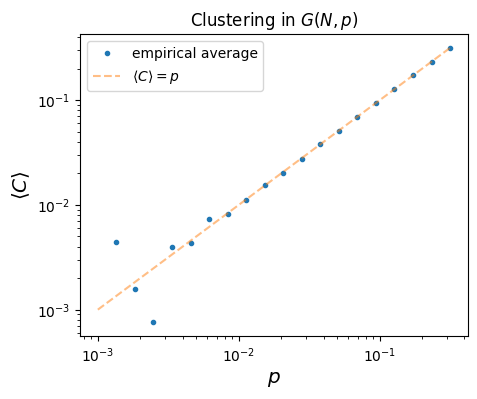

In [54]:
fig, ax = plt.subplots(1,1,figsize=(5,4),dpi=100)

ax.loglog(ps, clustering, marker='.', lw=0, label='empirical average')
ax.loglog(ps, ps, label=r'$\langle C \rangle = p$', alpha=0.5, ls='--')

ax.legend()
ax.set_xlabel(r'$p$', fontsize='x-large')
ax.set_ylabel(r'$\langle C \rangle$', fontsize='x-large')

ax.set_title(r'Clustering in $G(N,p)$')

plt.show()

____________

#### Want more? In your own time...

1. The **weighted clustering** of node $i$ in an undirected weighted graph $G$ can be defined as:

$$ C^w(i) = \frac{1}{s_i(k_i-1)} \sum_{j=1}^N\sum_{h=1}^N \frac{w_{ij} + w_{ih}}{2}A_{ij}A_{ih}A_{jh} $$

where $s_i$ is the *strength* of node $i$, $k_i$ is the degree of node $i$, and $w_{ij}$ is the weight associated to the edge connecting nodes $i$ and $j$.

Write a function that computes the weighted clusterings $C^w(i)$ for all nodes in an undirected weighted graph.

In [55]:
pass

_________
2. Use a *depth-first search* (DFS) to find connected components in a graph.

Below is an example of the order that nodes are searched in DFS.

![https://upload.wikimedia.org/wikipedia/commons/1/1f/Depth-first-tree.svg](https://upload.wikimedia.org/wikipedia/commons/1/1f/Depth-first-tree.svg)

And a helpful gif:
![images/DFS.gif](images/DFS.gif)

In [56]:
pass

__________
## Next time...
Degree, path lengths, triangles: these are all different ways to understand an individual node's role/status/importance in networks. Next time, we'll start to ask about distributions of network properties & explore even more centralities! `class_04_distributions.ipynb`
_______

## References and further resources:

1. Class Webpages
    - Jupyter Book: https://computational-methods-network-science.github.io/nets7052_fa26/README.html
    - Github: https://github.com/computational-methods-network-science/nets7052_fa26/
    - Syllabus and course details: https://brennanklein.com/nets7052-fall26
2. Fagiolo, G. (2007). Clustering in complex directed networks. *Physical Review E*, 76(2), 026107.
3. Network Science textbook (https://networksciencebook.com/).
4. Watts, D.J. & Strogatz, S.H. (1998). Collective dynamics of ‘small-world’ networks. *Nature*, 393: 409–10.

__________